# 서울 지하철 이용자 예측 회귀 모델링 (하이퍼파라미터 튜닝 버전)
> 목표: 검증 손실(Val Loss) 0.05 미만 달성
> 튜닝 항목: 학습률, 에폭, 은닉층 뉴런 수, 드롭아웃 비율, LR 스케줄러 추가

# 0. 라이브러리 불러오기

In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

# 미니배치 학습을 위한 DataLoader
from torch.utils.data import TensorDataset, DataLoader

# [튜닝 변경] ReduceLROnPlateau 대신 CosineAnnealingWarmRestarts 사용
# ReduceLROnPlateau: LR이 한 번 줄면 다시 안 올라감 → 300 에폭 이후 val loss 개선 없음
# CosineAnnealingWarmRestarts: 주기적으로 LR을 다시 올려줌(warm restart) → 지역 최솟값 탈출 가능
# 기존: from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 장치:", device)


사용 장치: cpu


# 1. 데이터 로드

In [127]:
# [튜닝 수정] 실제 데이터 파일 경로로 변경
# 기존: pd.read_csv("subway_train.csv")
# 기존: pd.read_csv("subway_test.csv")
train_df = pd.read_csv("subway_train.csv")
test_df = pd.read_csv("subway_test.csv")

# 데이터 앞 5행 확인
print(train_df.head())

# 데이터 구조 확인
print(train_df.info())

# 결측치 확인
print(train_df.isnull().sum())


         date day_of_week  month     station_name  visibility  precipitation  \
0  2023-01-01      Sunday      1   Jamsil Station    9.047399       2.136081   
1  2023-01-03      Friday      1  Hongdae Station   13.319895      16.647143   
2  2023-01-04      Sunday      1   Sillim Station   12.551289      18.386217   
3  2023-01-06      Friday      1  Hongdae Station    5.350641      19.170438   
4  2023-01-07      Friday      1    Seoul Station    8.592605       8.924651   

   temperature  num_people  
0    18.023113       13075  
1    11.032550       12454  
2    12.342243       10093  
3    30.787836       13413  
4    -0.677078       10889  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           900 non-null    object 
 1   day_of_week    900 non-null    object 
 2   month          900 non-null    int64  
 3   station_name   8

# 2. 결측치 처리

In [128]:
# visibility 결측치는 평균값으로 채움
train_df["visibility"] = train_df["visibility"].fillna(train_df["visibility"].mean())

# station_name 결측치는 unknown으로 채움
train_df["station_name"] = train_df["station_name"].fillna("unknown")

# 결측치 처리 결과 확인
print(train_df.isnull().sum())

date             0
day_of_week      0
month            0
station_name     0
visibility       0
precipitation    0
temperature      0
num_people       0
dtype: int64


# 3. 변수 정의

In [129]:
# 학습에 사용하지 않을 컬럼
COL_DEL = ["date"]

# 수치형 입력 변수
COL_NUM = ["visibility", "precipitation", "temperature"]

# 범주형 입력 변수
COL_CAT = ["day_of_week", "month", "station_name"]

# 예측 대상 컬럼
COL_Y = "num_people"

# 4. 간단한 데이터 시각화

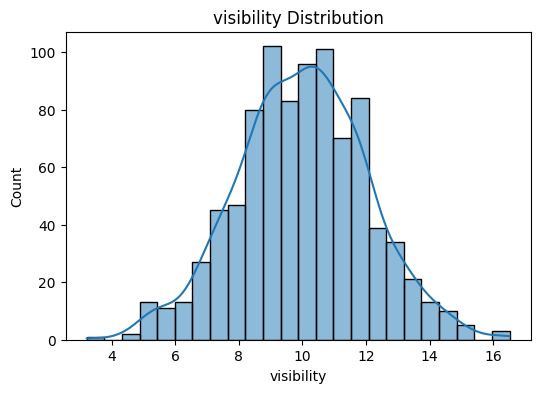

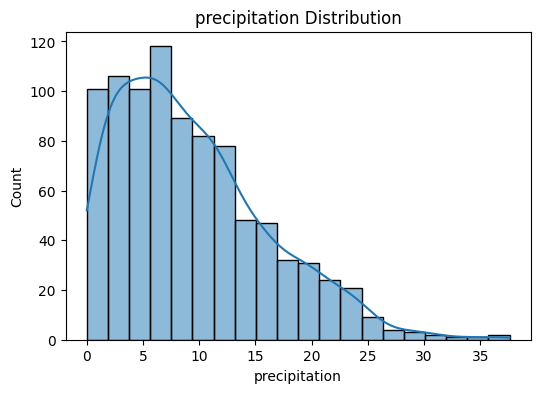

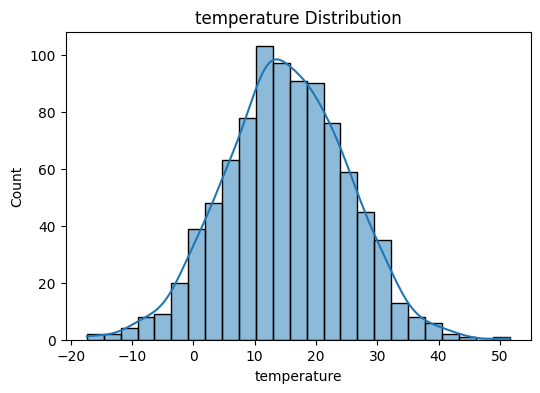

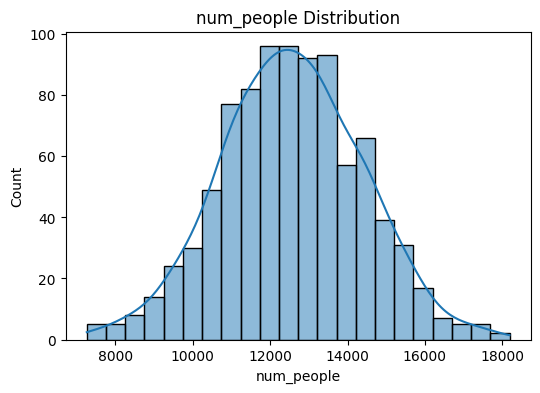

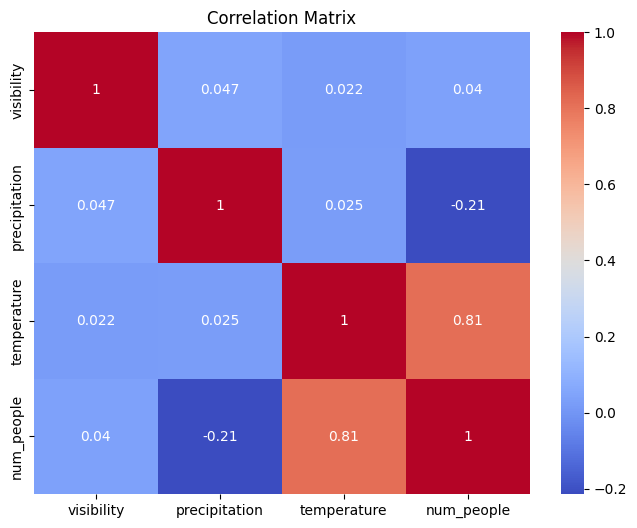

In [130]:
# 수치형 변수 분포 확인
for col in COL_NUM:
    plt.figure(figsize=(6, 4))
    sns.histplot(train_df[col], kde=True)
    plt.title(f"{col} Distribution")
    plt.show()

# 목표값 분포 확인
plt.figure(figsize=(6, 4))
sns.histplot(train_df[COL_Y], kde=True)
plt.title("num_people Distribution")
plt.show()

# 상관관계 확인
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[COL_NUM + [COL_Y]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 5. 이상값 처리 함수

In [131]:
def handle_outliers_iqr(df, col):
    # 1사분위수
    q1 = df[col].quantile(0.25)

    # 3사분위수
    q3 = df[col].quantile(0.75)

    # IQR 계산
    iqr = q3 - q1

    # 하한값
    lower_bound = q1 - 1.5 * iqr

    # 상한값
    upper_bound = q3 + 1.5 * iqr

    # 하한보다 작은 값은 하한으로 변경
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

    # 상한보다 큰 값은 상한으로 변경
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

    return df


# 수치형 변수에 이상값 처리 적용
for col in COL_NUM:
    train_df = handle_outliers_iqr(train_df, col)

# 6. 범주형 변수 인코딩 (임베딩용 LabelEncoder)

In [132]:
# [변경] 임베딩 레이어에는 정수 인덱스가 필요하므로 LabelEncoder 사용
# 기존: pd.get_dummies() 원-핫 인코딩
label_encoders = {}

for col in COL_CAT:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col].astype(str))
    label_encoders[col] = le
    print(f"{col}: {len(le.classes_)}개 카테고리")

# 임베딩 레이어 크기 결정에 사용
num_stations = len(label_encoders["station_name"].classes_)
num_days     = len(label_encoders["day_of_week"].classes_)
num_months   = len(label_encoders["month"].classes_)

print(f"\nstation_name 고유값: {num_stations}")
print(f"day_of_week 고유값: {num_days}")
print(f"month 고유값: {num_months}")


day_of_week: 7개 카테고리
month: 12개 카테고리
station_name: 6개 카테고리

station_name 고유값: 6
day_of_week 고유값: 7
month 고유값: 12


# 7. 수치형 변수 스케일링 (log1p + StandardScaler)

In [133]:
# [변경 추가] log1p 변환: num_people 분포가 오른쪽으로 치우칠 경우 정규화 효과
# log1p(x) = log(1+x) → 큰 값은 압축, 작은 값은 보존, 0도 안전하게 처리
# 역변환: expm1(x) = e^x - 1 (예측 후 원래 단위로 복원할 때 사용)
# 기존: 없음
train_df[COL_Y] = np.log1p(train_df[COL_Y])

# 입력값 스케일러
x_scaler = StandardScaler()
train_df[COL_NUM] = x_scaler.fit_transform(train_df[COL_NUM])

# 목표값 스케일러 (log1p 변환 이후 StandardScaler 적용)
# 역변환 순서: inverse_transform → expm1
y_scaler = StandardScaler()
train_df[[COL_Y]] = y_scaler.fit_transform(train_df[[COL_Y]])

print(COL_Y, COL_NUM)

num_people ['visibility', 'precipitation', 'temperature']


# 8. 학습 데이터와 검증 데이터 분리

In [134]:
# 입력 데이터 X 생성
X = train_df.drop(COL_DEL + [COL_Y], axis=1)

# 정답 데이터 y 생성
y = train_df[[COL_Y]]

# 학습용 80%, 검증용 20%로 분리
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)

X_train shape: (720, 6)
X_val shape: (180, 6)
y_train shape: (720, 1)
y_val shape: (180, 1)


# 9. PyTorch Tensor 변환

In [135]:
# [변경] 임베딩을 위해 범주형/연속형 텐서 분리
# 임베딩 레이어는 정수(long) 인덱스를 입력으로 받음
# 기존: X 전체를 하나의 float32 텐서로 변환

# 범주형 컬럼 (임베딩 입력용, long 타입)
CAT_COLS = ["day_of_week", "month", "station_name"]

# 연속형 컬럼 (일반 선형 레이어 입력용)
NUM_COLS = [c for c in X_train.columns if c not in CAT_COLS]

# 연속형 텐서 (float32)
X_train_num = torch.tensor(X_train[NUM_COLS].values, dtype=torch.float32).to(device)
X_val_num   = torch.tensor(X_val[NUM_COLS].values,   dtype=torch.float32).to(device)

# 범주형 텐서 (long: nn.Embedding 입력 요건)
X_train_cat = torch.tensor(X_train[CAT_COLS].values, dtype=torch.long).to(device)
X_val_cat   = torch.tensor(X_val[CAT_COLS].values,   dtype=torch.long).to(device)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).to(device)
y_val_tensor   = torch.tensor(y_val.values,   dtype=torch.float32).to(device)

print("X_train_num:", X_train_num.shape, "  ← 연속형 피처")
print("X_train_cat:", X_train_cat.shape, "  ← 범주형 인덱스 (임베딩 입력)")


X_train_num: torch.Size([720, 3])   ← 연속형 피처
X_train_cat: torch.Size([720, 3])   ← 범주형 인덱스 (임베딩 입력)


# 10. PyTorch 회귀 모델 정의

In [136]:
class SubwayRegressionModel(nn.Module):
    def __init__(self, num_days, num_months, num_stations, num_cont_features):
        super().__init__()

        # [변경] 임베딩 레이어: 정수 인덱스 → 밀집 벡터(dense vector)
        # 원-핫 인코딩과 달리 임베딩은 역 간 유사도를 학습 가능
        # 임베딩 차원 공식: min(50, (카테고리 수 + 1) // 2)
        # 기존: 원-핫 인코딩으로 sparse 컬럼 생성
        day_emb_dim     = min(50, (num_days + 1) // 2)      # 요일: 3~4차원
        month_emb_dim   = min(50, (num_months + 1) // 2)    # 월: 6차원
        station_emb_dim = min(50, (num_stations + 1) // 2)  # 역: 최대 50차원

        self.day_emb     = nn.Embedding(num_days,     day_emb_dim)
        self.month_emb   = nn.Embedding(num_months,   month_emb_dim)
        self.station_emb = nn.Embedding(num_stations, station_emb_dim)

        # 첫 번째 레이어 입력 = 연속형 피처 + 모든 임베딩 합산
        total_input = num_cont_features + day_emb_dim + month_emb_dim + station_emb_dim

        self.fc1    = nn.Linear(total_input, 128)
        self.fc2    = nn.Linear(128, 64)
        self.fc3    = nn.Linear(64, 32)
        self.output = nn.Linear(32, 1)

        # self.fc1    = nn.Linear(total_input, 64)
        # self.fc2    = nn.Linear(64, 32)
        # self.fc3    = nn.Linear(32, 8)
        # self.output = nn.Linear(8, 1)

        self.relu    = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x_num, x_cat):
        # 범주형 인덱스 분리 (CAT_COLS 순서: day_of_week, month, station_name)
        day_emb     = self.day_emb(x_cat[:, 0])
        month_emb   = self.month_emb(x_cat[:, 1])
        station_emb = self.station_emb(x_cat[:, 2])

        # 연속형 피처 + 임베딩 결합
        x = torch.cat([x_num, day_emb, month_emb, station_emb], dim=1)

        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.output(x)
        return x


num_cont_features = X_train_num.shape[1]
model = SubwayRegressionModel(num_days, num_months, num_stations, num_cont_features).to(device)
print(model)
print(f"\n임베딩 차원 → 요일: {model.day_emb.embedding_dim}, 월: {model.month_emb.embedding_dim}, 역: {model.station_emb.embedding_dim}")


SubwayRegressionModel(
  (day_emb): Embedding(7, 4)
  (month_emb): Embedding(12, 6)
  (station_emb): Embedding(6, 3)
  (fc1): Linear(in_features=16, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (output): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)

임베딩 차원 → 요일: 4, 월: 6, 역: 3


# 11. 손실 함수와 최적화 함수 설정

In [137]:
criterion = nn.MSELoss()

# [튜닝] 학습률
# 기존: lr=0.001, weight_decay=1e-3  ← 2차 튜닝값
# 기존: lr=0.00005, weight_decay=1e-2
optimizer = optim.Adam(model.parameters(), lr=0.00001, weight_decay=1e-2)

# [튜닝 변경] CosineAnnealingWarmRestarts로 교체
# T_0=200: 200 에폭마다 LR이 최솟값(eta_min)에서 최댓값(lr)으로 리셋됨
# T_mult=1: 매 주기 길이 동일
# eta_min=1e-5: LR의 최솟값
# 효과: LR이 내려갔다가 다시 올라가며 지역 최솟값에서 탈출 → val loss 계속 개선 가능
# 기존: ReduceLROnPlateau(patience=150) ← 2차 튜닝값 (LR이 내려가기만 함)
scheduler = CosineAnnealingWarmRestarts(
    optimizer,
    T_0=200,
    T_mult=1,
    eta_min=1e-5
)


# 12. 모델 학습

In [138]:
EPOCHS = 2000
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_num, X_train_cat, y_train_tensor)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

train_loss_history = []
val_loss_history   = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0

    for X_batch_num, X_batch_cat, y_batch in train_loader:
        pred  = model(X_batch_num, X_batch_cat).squeeze()
        loss  = criterion(pred, y_batch.squeeze())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    scheduler.step()

    avg_train_loss = epoch_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        val_pred = model(X_val_num, X_val_cat).squeeze()
        val_loss = criterion(val_pred, y_val_tensor.squeeze()).item()

    train_loss_history.append(avg_train_loss)
    val_loss_history.append(val_loss)

    if (epoch + 1) % 100 == 0:
        current_lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f}")


Epoch [100/2000] | Train Loss: 0.8399 | Val Loss: 0.8999 | LR: 0.000010
Epoch [200/2000] | Train Loss: 0.4801 | Val Loss: 0.4015 | LR: 0.000010
Epoch [300/2000] | Train Loss: 0.3616 | Val Loss: 0.2330 | LR: 0.000010
Epoch [400/2000] | Train Loss: 0.3054 | Val Loss: 0.2104 | LR: 0.000010
Epoch [500/2000] | Train Loss: 0.2935 | Val Loss: 0.2016 | LR: 0.000010
Epoch [600/2000] | Train Loss: 0.2652 | Val Loss: 0.1936 | LR: 0.000010
Epoch [700/2000] | Train Loss: 0.2370 | Val Loss: 0.1871 | LR: 0.000010
Epoch [800/2000] | Train Loss: 0.2246 | Val Loss: 0.1822 | LR: 0.000010
Epoch [900/2000] | Train Loss: 0.2367 | Val Loss: 0.1781 | LR: 0.000010
Epoch [1000/2000] | Train Loss: 0.2216 | Val Loss: 0.1748 | LR: 0.000010
Epoch [1100/2000] | Train Loss: 0.2090 | Val Loss: 0.1716 | LR: 0.000010
Epoch [1200/2000] | Train Loss: 0.2107 | Val Loss: 0.1682 | LR: 0.000010
Epoch [1300/2000] | Train Loss: 0.1966 | Val Loss: 0.1670 | LR: 0.000010
Epoch [1400/2000] | Train Loss: 0.1960 | Val Loss: 0.1659 | 

# 13. 검증 데이터 평가

In [139]:
model.eval()
with torch.no_grad():
    val_preds = model(X_val_num, X_val_cat).squeeze().cpu().numpy().reshape(-1, 1)

val_pred_original = np.expm1(y_scaler.inverse_transform(val_preds))
y_val_original    = np.expm1(y_scaler.inverse_transform(y_val_tensor.cpu().numpy().reshape(-1, 1)))

rmse = np.sqrt(mean_squared_error(y_val_original, val_pred_original))
r2   = r2_score(y_val_original, val_pred_original)

print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")
print(f"\n최종 Val Loss: {val_loss_history[-1]:.4f}")
print(f"최소 Val Loss: {min(val_loss_history):.4f} (epoch {val_loss_history.index(min(val_loss_history))+1})")


RMSE: 721.13
R²:   0.8535

최종 Val Loss: 0.1587
최소 Val Loss: 0.1582 (epoch 1986)


# 14. 학습 손실 시각화

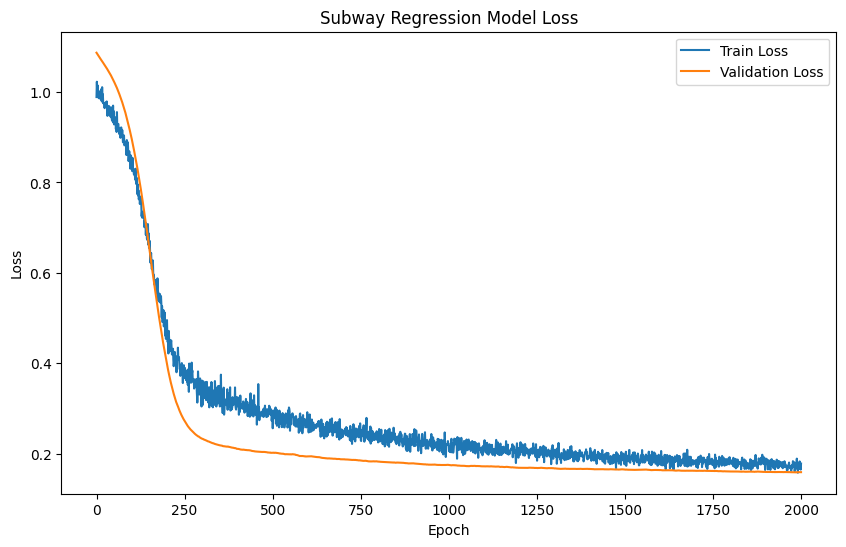

In [140]:
plt.figure(figsize=(10, 6))

# 학습 손실 그래프
plt.plot(train_loss_history, label="Train Loss")

# 검증 손실 그래프
plt.plot(val_loss_history, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Subway Regression Model Loss")
plt.legend()
plt.show()

# 15. 실제값과 예측값 비교 시각화

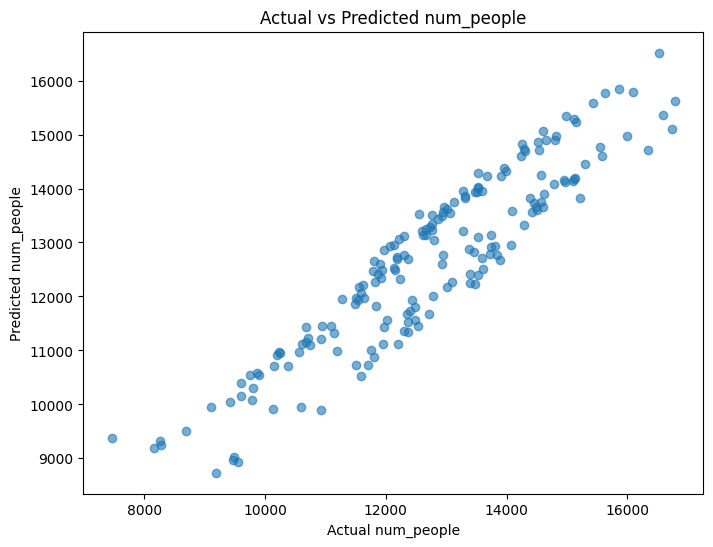

In [141]:
plt.figure(figsize=(8, 6))

# 실제값과 예측값 산점도
plt.scatter(y_val_original, val_pred_original, alpha=0.6)

plt.xlabel("Actual num_people")
plt.ylabel("Predicted num_people")
plt.title("Actual vs Predicted num_people")
plt.show()

# 테스트 데이터 복사

In [142]:
# [변경] 임베딩을 위한 LabelEncoder 변환 (훈련 셋에서 fit 된 인코더 재사용)
# 기존: pd.get_dummies + reindex로 원-핫 컬럼 맞추기

for col in COL_CAT:
    le = label_encoders[col]
    # 훈련 때 보지 못한 카테고리 → -1로 표시 후 0으로 대체 (안전 처리)
    known = set(le.classes_)
    test_df[col] = test_df[col].astype(str).apply(
        lambda v: le.transform([v])[0] if v in known else 0
    )

# 수치형 스케일링 (훈련 x_scaler 재사용)
test_df[COL_NUM] = x_scaler.transform(test_df[COL_NUM])


# 17. 테스트 데이터 예측

In [143]:
X_test_num = torch.tensor(test_df[NUM_COLS].values, dtype=torch.float32).to(device)
X_test_cat = torch.tensor(test_df[CAT_COLS].values, dtype=torch.long).to(device)

model.eval()
with torch.no_grad():
    test_preds = model(X_test_num, X_test_cat).squeeze().cpu().numpy().reshape(-1, 1)

test_pred_original = np.expm1(y_scaler.inverse_transform(test_preds))

submission_df = pd.DataFrame({"id": test_preds, "num_people": test_pred_original.flatten()})
submission_df.to_csv("subway_submission.csv", index=False)
print(submission_df.head(10))


ValueError: Per-column arrays must each be 1-dimensional

# 18. 테스트 데이터에 실제 정답이 있는 경우 평가

In [ ]:
if has_target:
    # test 데이터의 실제값은 원래 단위라고 가정
    y_test_original = y_test.values

    # MSE 계산
    test_mse = mean_squared_error(y_test_original, test_pred_original)

    # R2 Score 계산
    test_r2 = r2_score(y_test_original, test_pred_original)

    print("Test MSE:", test_mse)
    print("Test R2 Score:", test_r2)

# 19. 예측 결과 저장

In [ ]:
# 결과 저장용 데이터프레임 생성
result_df = test_df.copy()

# 예측 이용자 수 컬럼 추가
result_df["predicted_num_people"] = test_pred_original

# CSV 파일로 저장
result_df.to_csv("subway_pytorch_prediction.csv", index=False)

print("subway_pytorch_prediction.csv 파일이 생성되었습니다.")
print(result_df.head())